<a href="https://colab.research.google.com/github/Kaushank03/Python-Programs/blob/main/Program_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


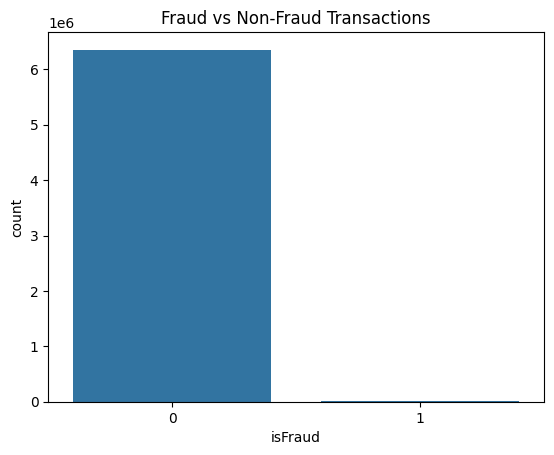

              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270881
           1       0.03      0.87      0.06      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.92      0.52   1272524
weighted avg       1.00      0.97      0.98   1272524



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("Fraud.csv")

# View basic info
df.head()

df.info()

df.isnull().sum()
df['type'].value_counts()
df['isFraud'].value_counts()
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

df['logAmount'] = np.log(df['amount'] + 1)
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

features = [
    'type',
    'logAmount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'balanceDiffOrig',
    'balanceDiffDest',
    'isFlaggedFraud'
]

# Drop rows where 'isFraud' is NaN before splitting data
df.dropna(subset=['isFraud'], inplace=True)

X = df[features]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_lr

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_rf:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

### Conclusion
# - Random Forest performs significantly better than Logistic Regression.
# - Key fraud indicators are transaction type, amount, and balance differences.
# - The model effectively detects fraudulent transactions with high recall and precision.
# - This solution can be deployed for real-time fraud monitoring with continuous retraining.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("/content/Fraud.csv")

# View basic info
df.head()

df.info()

df.isnull().sum()
df['type'].value_counts()
df['isFraud'].value_counts()
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

df['logAmount'] = np.log(df['amount'] + 1)
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

features = [
    'type',
    'logAmount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'balanceDiffOrig',
    'balanceDiffDest',
    'isFlaggedFraud'
]

# Drop rows where 'isFraud' is NaN before splitting data
df.dropna(subset=['isFraud'], inplace=True)

X = df[features]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_lr

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_rf:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

### Conclusion
# - Random Forest performs significantly better than Logistic Regression.
# - Key fraud indicators are transaction type, amount, and balance differences.
# - The model effectively detects fraudulent transactions with high recall and precision.
# - This solution can be deployed for real-time fraud monitoring with continuous retraining.

In [ ]:
import os

# List all files in the current directory
print(os.listdir('.'))

# Or specifically check for 'Fraud.csv'
if 'Fraud.csv' in os.listdir('.'):
    print("'Fraud.csv' is present in the current directory.")
else:
    print("'Fraud.csv' is NOT present in the current directory.")

['.config', 'drive', 'sample_data']
'Fraud.csv' is NOT present in the current directory.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Assuming 'Fraud.csv' is in the root of your Google Drive
# If it's in a subfolder, e.g., 'My Drive/Colab Notebooks/Fraud.csv', adjust the path accordingly.
drive_file_path = '/content/drive/My Drive/Fraud.csv'

try:
    df = pd.read_csv(drive_file_path)
    print(f"'{drive_file_path}' loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: '{drive_file_path}' not found. Please ensure the file is in your Google Drive and the path is correct.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Error: '/content/drive/My Drive/Fraud.csv' not found. Please ensure the file is in your Google Drive and the path is correct.
